# Generate polycrystals for MOOSE

Notebook to generate polycrystals for MOOSE with the desired grain size, elongation, texture. It saves the grain structure into the format of EBSD data.

This jupyter notebook is being published with the following paper:

P.-C. A. Simon, L. K. Aagesen, C. Jiang, W. Jiang, J.-H. Ke, Multiscale calculation of the effective silver diffusion coefficient in polycrystalline silicon carbide: application to silver release in AGR-1 TRISO particles, Journal of Nuclear Materials, 563 (2022) 153669.
[https://doi.org/10.1016/j.jnucmat.2022.153669](https://doi.org/10.1016/j.jnucmat.2022.153669)

Contact: Pierre-Clément A. Simon - [pierreclement.simon@inl.gov](mailto:pierreclement.simon@inl.gov)

## Import

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d
from skimage import measure
import numpy as np
import math

## Initialize Input parameters

In [2]:
# Basic domain and grain size parameters
domain_size = 1000 # square domain size
num_grain_vertically = 4
num_grain_horizontally = 4
ratio_elongation = num_grain_vertically/num_grain_horizontally # elongation ratio: x/y - 1 for equiaxed. - if ratio_elongation>1, then the grain are elongated horizontally
mesh_size = 50
domain_center_x = 0
domain_center_y = 0

# Parameters for grain orientation
random = 1 # 0 for no randomness or 1 for randomness in the position of the centroids.
mean_angle = 0
std_angle = 20 # 20

# Prepare file names
filename_base = f"../EBSD_files/Polycrystal_Domain_{domain_size}_NumGrainHor_{num_grain_horizontally}_NumGrainVert_{num_grain_vertically}"
filename_EBSD = f"{filename_base}.txt"




## Generate the grain centroids

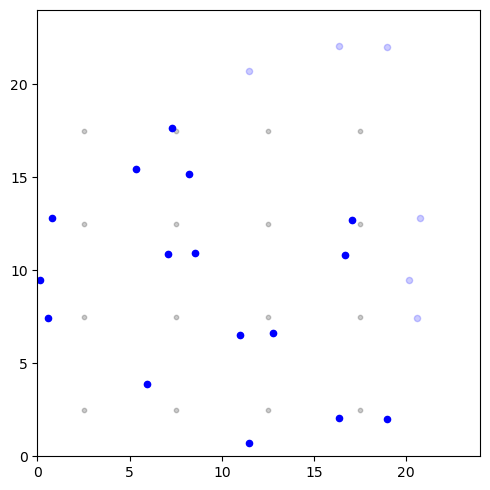

The number of centroids is equal to:  16


In [3]:
# Create a larger domain for elongation
domain_size_elongation_x = domain_size / mesh_size
domain_size_elongation_y = domain_size / mesh_size * ratio_elongation

# Generate uniform base grid
grain_diameter = domain_size_elongation_y / num_grain_vertically
num_grain_y = num_grain_vertically
num_grain_x = math.ceil(num_grain_vertically / ratio_elongation)
grain_centroid_elongation_vect_y = grain_diameter * np.linspace(0.5, num_grain_y-0.5, num=num_grain_y)
grain_centroid_elongation_vect_x = grain_diameter * np.linspace(0.5, num_grain_x-0.5, num=num_grain_x)

# Generate random variations
zeromat = np.zeros((num_grain_y,num_grain_x))
randx = np.random.rand(num_grain_y,num_grain_x)*grain_diameter*random
randy = np.random.rand(num_grain_y,num_grain_x)*grain_diameter*random

# Derive grain centroids
grain_centroid_elongated_mat_x_fix = np.zeros((num_grain_y,num_grain_x))
grain_centroid_elongated_mat_y_fix =  np.zeros((num_grain_y,num_grain_x))
grain_centroid_elongated_mat_x =  np.zeros((num_grain_y,num_grain_x))
grain_centroid_elongated_mat_y =  np.zeros((num_grain_y,num_grain_x))

for i in range(num_grain_x):
    grain_centroid_elongated_mat_x_fix[:,i] = grain_centroid_elongation_vect_x[i] + zeromat[:,i]
    grain_centroid_elongated_mat_x[:,i] = grain_centroid_elongation_vect_x[i] + randx[:,i]

for j in range(num_grain_y):
    grain_centroid_elongated_mat_y_fix[j,:] = grain_centroid_elongation_vect_y[j] + zeromat[j,:]
    grain_centroid_elongated_mat_y[j,:] = grain_centroid_elongation_vect_y[j] + randy[j,:]

# transform grain_centroid_elongated_mat_x and grain_centroid_elongated_mat_y into 1-dim arrays
grain_centroid_elongated_vect_long_x = np.array([])
grain_centroid_elongated_vect_long_y = np.array([])
for i in range(len(grain_centroid_elongated_mat_x)):
    grain_centroid_elongated_vect_long_x = np.append(grain_centroid_elongated_vect_long_x,grain_centroid_elongated_mat_x[i])
    grain_centroid_elongated_vect_long_y = np.append(grain_centroid_elongated_vect_long_y,grain_centroid_elongated_mat_y[i])

# randomize grain indices (for the plots below)
perm = np.random.permutation(num_grain_y*num_grain_x)
grain_centroid_elongated_vect_long_perm_x = np.zeros((num_grain_y*num_grain_x))
grain_centroid_elongated_vect_long_perm_y = np.zeros((num_grain_y*num_grain_x))
for i in range(num_grain_y*num_grain_x):
        grain_centroid_elongated_vect_long_perm_x[perm[i]] = grain_centroid_elongated_vect_long_x[i]
        grain_centroid_elongated_vect_long_perm_y[perm[i]] = grain_centroid_elongated_vect_long_y[i]

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
plt.scatter(grain_centroid_elongated_mat_x_fix,grain_centroid_elongated_mat_y_fix, alpha = 0.2, s=10, color = 'black')
plt.scatter(grain_centroid_elongated_mat_x,grain_centroid_elongated_mat_y, alpha = 0.2, s=20, color = 'blue')
plt.scatter(grain_centroid_elongated_mat_x%domain_size_elongation_x,grain_centroid_elongated_mat_y%domain_size_elongation_y, alpha = 1, s=20, color = 'blue')
ax.set_xlim(0, domain_size_elongation_x*(1.2))
ax.set_ylim(0, domain_size_elongation_y*(1.2))
fig.tight_layout()
# plt.savefig(filename_base + "_Grain_structure_Generator_Centroids.pdf")
plt.show()

print("The number of centroids is equal to: ", num_grain_y*num_grain_x)



## Voronoi tesselation

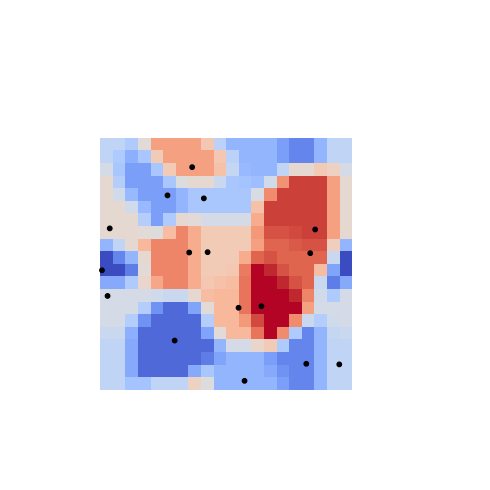

In [4]:
# Initialization
grain_structure_elongation = np.zeros((int(round(domain_size_elongation_y/ratio_elongation)+1),int(domain_size_elongation_x)+1)) # Indice of the grain at a given position
position_x = np.zeros((int(domain_size_elongation_x))+1) # position along x
position_y = np.zeros((int(round(domain_size_elongation_y/ratio_elongation)))+1) # position along y

# Voronoi tesselation
for i in range(round(domain_size_elongation_y/ratio_elongation)+1):
    position_y[i] = i*ratio_elongation
    for j in range(int(domain_size_elongation_x)+1):
        position_x[j] = j
        dist_vect = np.zeros((num_grain_x*num_grain_y,1))
        for q in range(num_grain_x*num_grain_y):
            # derive length along x
            dist_x =  j-grain_centroid_elongated_vect_long_perm_x[q]
            if abs(dist_x) > domain_size_elongation_x/2:
                if dist_x > 0:
                    dist_x =  j-domain_size_elongation_x-grain_centroid_elongated_vect_long_perm_x[q]
                else:
                    dist_x =  j+domain_size_elongation_x-grain_centroid_elongated_vect_long_perm_x[q]
            # derive length along y
            dist_y =  i*ratio_elongation-grain_centroid_elongated_vect_long_perm_y[q]
            if abs(dist_y) > domain_size_elongation_y/2:
                if dist_y > 0:
                    dist_y =  i*ratio_elongation-domain_size_elongation_y-grain_centroid_elongated_vect_long_perm_y[q]
                else:
                    dist_y =  i*ratio_elongation+domain_size_elongation_y-grain_centroid_elongated_vect_long_perm_y[q]

            dist_vect[q] = math.sqrt(dist_x*dist_x + dist_y*dist_y)

        min_dist_ind =  np.where(dist_vect == dist_vect.min())[0]
        grain_structure_elongation[i,j] = min_dist_ind[0]

# Plot the voronoi tesselation results
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection='3d')
ax.view_init(90, -90) # set to (90,90) for top view
ax.set_proj_type('ortho')
X, Y = np.meshgrid(position_x, position_y)
ax.plot_surface(X,Y, grain_structure_elongation, cmap=cm.coolwarm,linewidth=0, antialiased=False)
ax.scatter3D(grain_centroid_elongated_vect_long_perm_x%domain_size_elongation_x,grain_centroid_elongated_vect_long_perm_y%domain_size_elongation_y,100*np.ones(len(grain_centroid_elongated_vect_long_perm_x)), alpha = 1, s=10, color = 'black')
ax.set_xlim(0, domain_size_elongation_x*(1.2))
ax.set_ylim(0, domain_size_elongation_y*(1.2))
plt.axis('off')
fig.tight_layout()
# plt.savefig(filename_base + "_Grain_structure_Generator_Voronoi.pdf")
plt.show()


## Count the number of grains in the domain without taking periodic BC into account (for grain ids and grain orientation in MOOSE)

In [5]:
# initialize
num_grains_actual = 0
binary_matrix_single_grain = np.zeros((len(grain_structure_elongation),len(grain_structure_elongation[0])))

for i in range(int(np.amin(grain_structure_elongation)),int(np.amax(grain_structure_elongation))):
    binary_matrix_single_grain[grain_structure_elongation==i] = 1
    all_labels = measure.label(binary_matrix_single_grain)
    num_grains_actual = num_grains_actual + np.amax(all_labels)
    binary_matrix_single_grain[grain_structure_elongation==i] = 0

print('The number of grains in the microstructure (without periodicity) is equal to', num_grains_actual)

The number of grains in the microstructure (without periodicity) is equal to 24


## Scale the mesh, center it, and list the grain id at each position

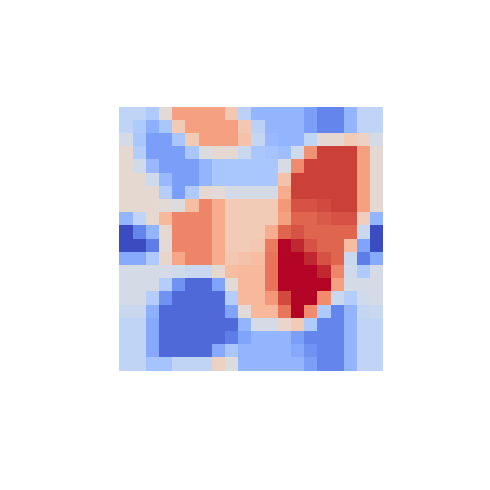

The original number of unique grains was equal to: 16
The number of unique grains is equal to: 16
test: All is good with mesh size and steps in x and y directions


In [28]:
# rescale for elongation and mesh size
position_x_mesh = position_x * mesh_size
position_y_mesh = position_y * mesh_size / ratio_elongation
position_y_mesh = position_y_mesh - np.amin(position_y_mesh)

#  center mesh
domain_min_x = domain_center_x - domain_size/2
domain_min_y = domain_center_y - domain_size/2
domain_max_x = domain_center_x + domain_size/2
domain_max_y = domain_center_y + domain_size/2
position_x_mesh = position_x_mesh + domain_min_x - mesh_size/2
position_y_mesh = position_y_mesh + domain_min_y - mesh_size/2

# Plot the final grain structure
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection='3d')
ax.view_init(90, -90) # set to (90,90) for top view
ax.set_proj_type('ortho')
X, Y = np.meshgrid(position_x_mesh, position_y_mesh)
ax.plot_surface(X,Y, grain_structure_elongation, cmap=cm.coolwarm,linewidth=0, antialiased=False)
fig.tight_layout()
plt.axis('off')
# plt.savefig(filename_base + "_Grain_structure_Generator_Voronoi_final.pdf")
plt.show()


# create verctors with the 2-dimensional arrays
position_x_vect = np.zeros(len(position_x_mesh)**2)
position_y_vect = np.zeros(len(position_x_mesh)**2)
grain_structure_vect = np.zeros(len(position_x_mesh)**2)-1
position_x_final = np.array([])
position_y_final = np.array([])
grain_structure_final = np.array([])

for i in range(len(position_y_mesh)):
    if (position_y_mesh[i]>domain_min_y) and (position_y_mesh[i]<domain_max_y):
        for j in range(len(position_x_mesh)):
            k = i+j*len(position_y_mesh)-1*len(position_y_mesh)
            if (position_x_mesh[j]>domain_min_x) and (position_x_mesh[j]<domain_max_x):
                position_x_vect[k] = position_x_mesh[j]
                position_y_vect[k] = position_y_mesh[i]
                grain_structure_vect[k] = grain_structure_elongation[i,j]

            if not(np.isnan(position_x_vect[k])) and (grain_structure_vect[k]!=-1):
                position_x_final = np.append(position_x_final,position_x_vect[k])
                position_y_final = np.append(position_y_final,position_y_vect[k])
                grain_structure_final = np.append(grain_structure_final,grain_structure_vect[k])

num_grains_actual_final = len(np.unique(grain_structure_final))
print('The original number of unique grains was equal to:', num_grain_y*num_grain_x)
print('The number of unique grains is equal to:', num_grains_actual_final)


# derive x_step and y_step (should be the same than mesh_size)
position_x_vect_test = np.unique(position_x_final)
x_step = position_x_vect_test[1]-position_x_vect_test[0]
position_y_vect_test = np.unique(position_y_final)
y_step = position_y_vect_test[2]-position_y_vect_test[1]

if (x_step==y_step) and (x_step==mesh_size):
    print('test: All is good with mesh size and steps in x and y directions')
else:
    print('Error with mesh size and steps in x and y directions. x_step = ', x_step, ', y_step = ', y_step, 'and mesh_size = ',mesh_size)

## Generate Euler Angles (enough to include the non-periodicity of the grains)

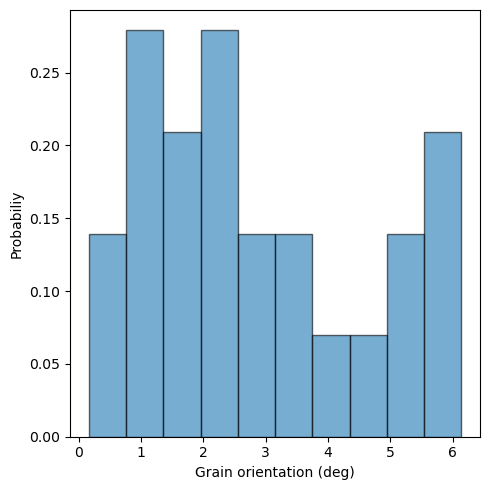

In [46]:
# generate euler angle
angle_deg_3params = np.zeros((num_grains_actual, 3))
angle_deg_3params[:,0] = np.random.uniform(0, 2*np.pi, num_grains_actual)
angle_deg_3params[:,1] = np.random.uniform(0, np.pi, num_grains_actual)
angle_deg_3params[:,2] = np.random.uniform(0, 2*np.pi, num_grains_actual)

# generate phase number
phase_index = np.random.choice([1, 2], size=num_grains_actual)

# Plot the histogram
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1,1,1)
counts, bins = np.histogram(angle_deg_3params[:,2])
plt.hist(bins[:-1], bins, weights=counts, density = True, alpha=0.6, histtype='bar', ec='black')
plt.xlabel('Grain orientation (deg)')
plt.ylabel('Probabiliy')
fig.tight_layout()
# plt.savefig(filename_base + "_Grain_structure_Generator_histogram.pdf")
plt.show()


## Save all in EBSD file

In [53]:

fileEBSD = open(filename_EBSD,"w")
L = ['# Header:    Marmot Input File \n',
    '# Date:      24-May-2021 00:23:55\n',
    '# \n',
    '# Column 1:  Euler angle "phi1" (in radians)\n',
    '# Column 2:  Euler angle "PHI" (in radians)\n',
    '# Column 3:  Euler angle "phi2" (in radians)\n',
    '# Column 4:  x-coordinate (in nm)\n',
    '# Column 5:  y-coordinate (in nm)\n',
    '# Column 6:  z-coordinate (in nm)\n',
    '# Column 7:  grain number (integer)\n',
    '# Column 8:  phase number (integer)\n',
    '# Column 9:  symmetry class (from TSL)\n',
    '#\n',
    '# Phase 1:   Li2O (symmetry class = 225)\n',
    f'# Number of Grains in Phase 1:  {num_grains_actual_final}\n',
    '#\n',
    f'# X_Min:      {domain_min_x}\n',
    f'# X_Max:      {domain_max_x}\n',
    f'# X_step:     {x_step}\n',
    f'# X_Dim:      {len(np.unique(position_x_final))}\n',
    '#\n',
    f'# Y_Min:      {domain_min_y}\n',
    f'# Y_Max:      {domain_max_y}\n',
    f'# Y_step:     {y_step}\n',
    f'# Y_Dim:      {len(np.unique(position_y_final))}\n',
    '#\n',
    '# Z_Min:      0.000000\n',
    '# Z_Max:      0.000000\n',
    '# Z_step:     0.000000\n',
    '# Z_Dim:      0\n',
    '#\n']
fileEBSD.writelines(L)

for i in range(len(position_x_final)):
    L = f"{angle_deg_3params[int(grain_structure_final[i]),0]:.5f} "\
        f"{angle_deg_3params[int(grain_structure_final[i]),1]:.5f} "\
        f"{angle_deg_3params[int(grain_structure_final[i]),2]:.5f} "\
        f"{position_x_final[i]:.5f} {position_y_final[i]:.5f} "\
        f"0.00000 {int(grain_structure_final[i]):>3} {phase_index[int(grain_structure_final[i])]} {225} \n"
    fileEBSD.write(L)

fileEBSD.close()


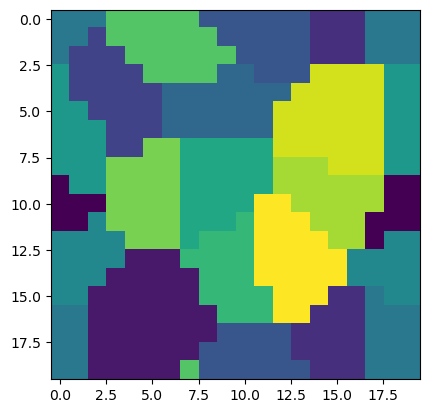

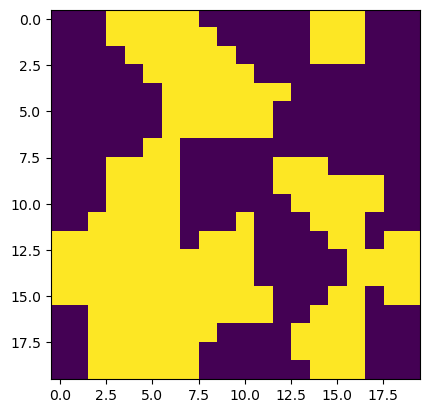

In [ ]:
# plot figure
grain_structure_final_copy = np.copy(grain_structure_final)
grain_structure_final_copy.resize(int(domain_size_elongation_x),int(domain_size_elongation_y))
poly_outline = np.flipud(grain_structure_final_copy)
plt.imshow(poly_outline)
plt.show()

phase_outline = np.zeros(poly_outline.shape)
for index, phase_ind in enumerate(phase_index):
    phase_outline += (phase_ind == 1) * (poly_outline == index)
plt.imshow(phase_outline)
plt.show()

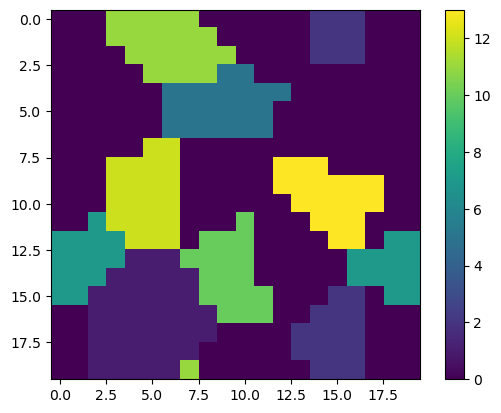

In [47]:
phase_index

array([2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1,
       1, 2])